In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import colorcet as cc

In [11]:
era5_dataset = xr.load_dataset("/home/leoseen/aos_773/final_project/era5_reanalysis_2025.grib", engine = 'cfgrib')
spole_data = era5_dataset.t.sel(latitude = '-90', longitude = '-180.0')
spole_daily_data = spole_data.groupby('time.date')

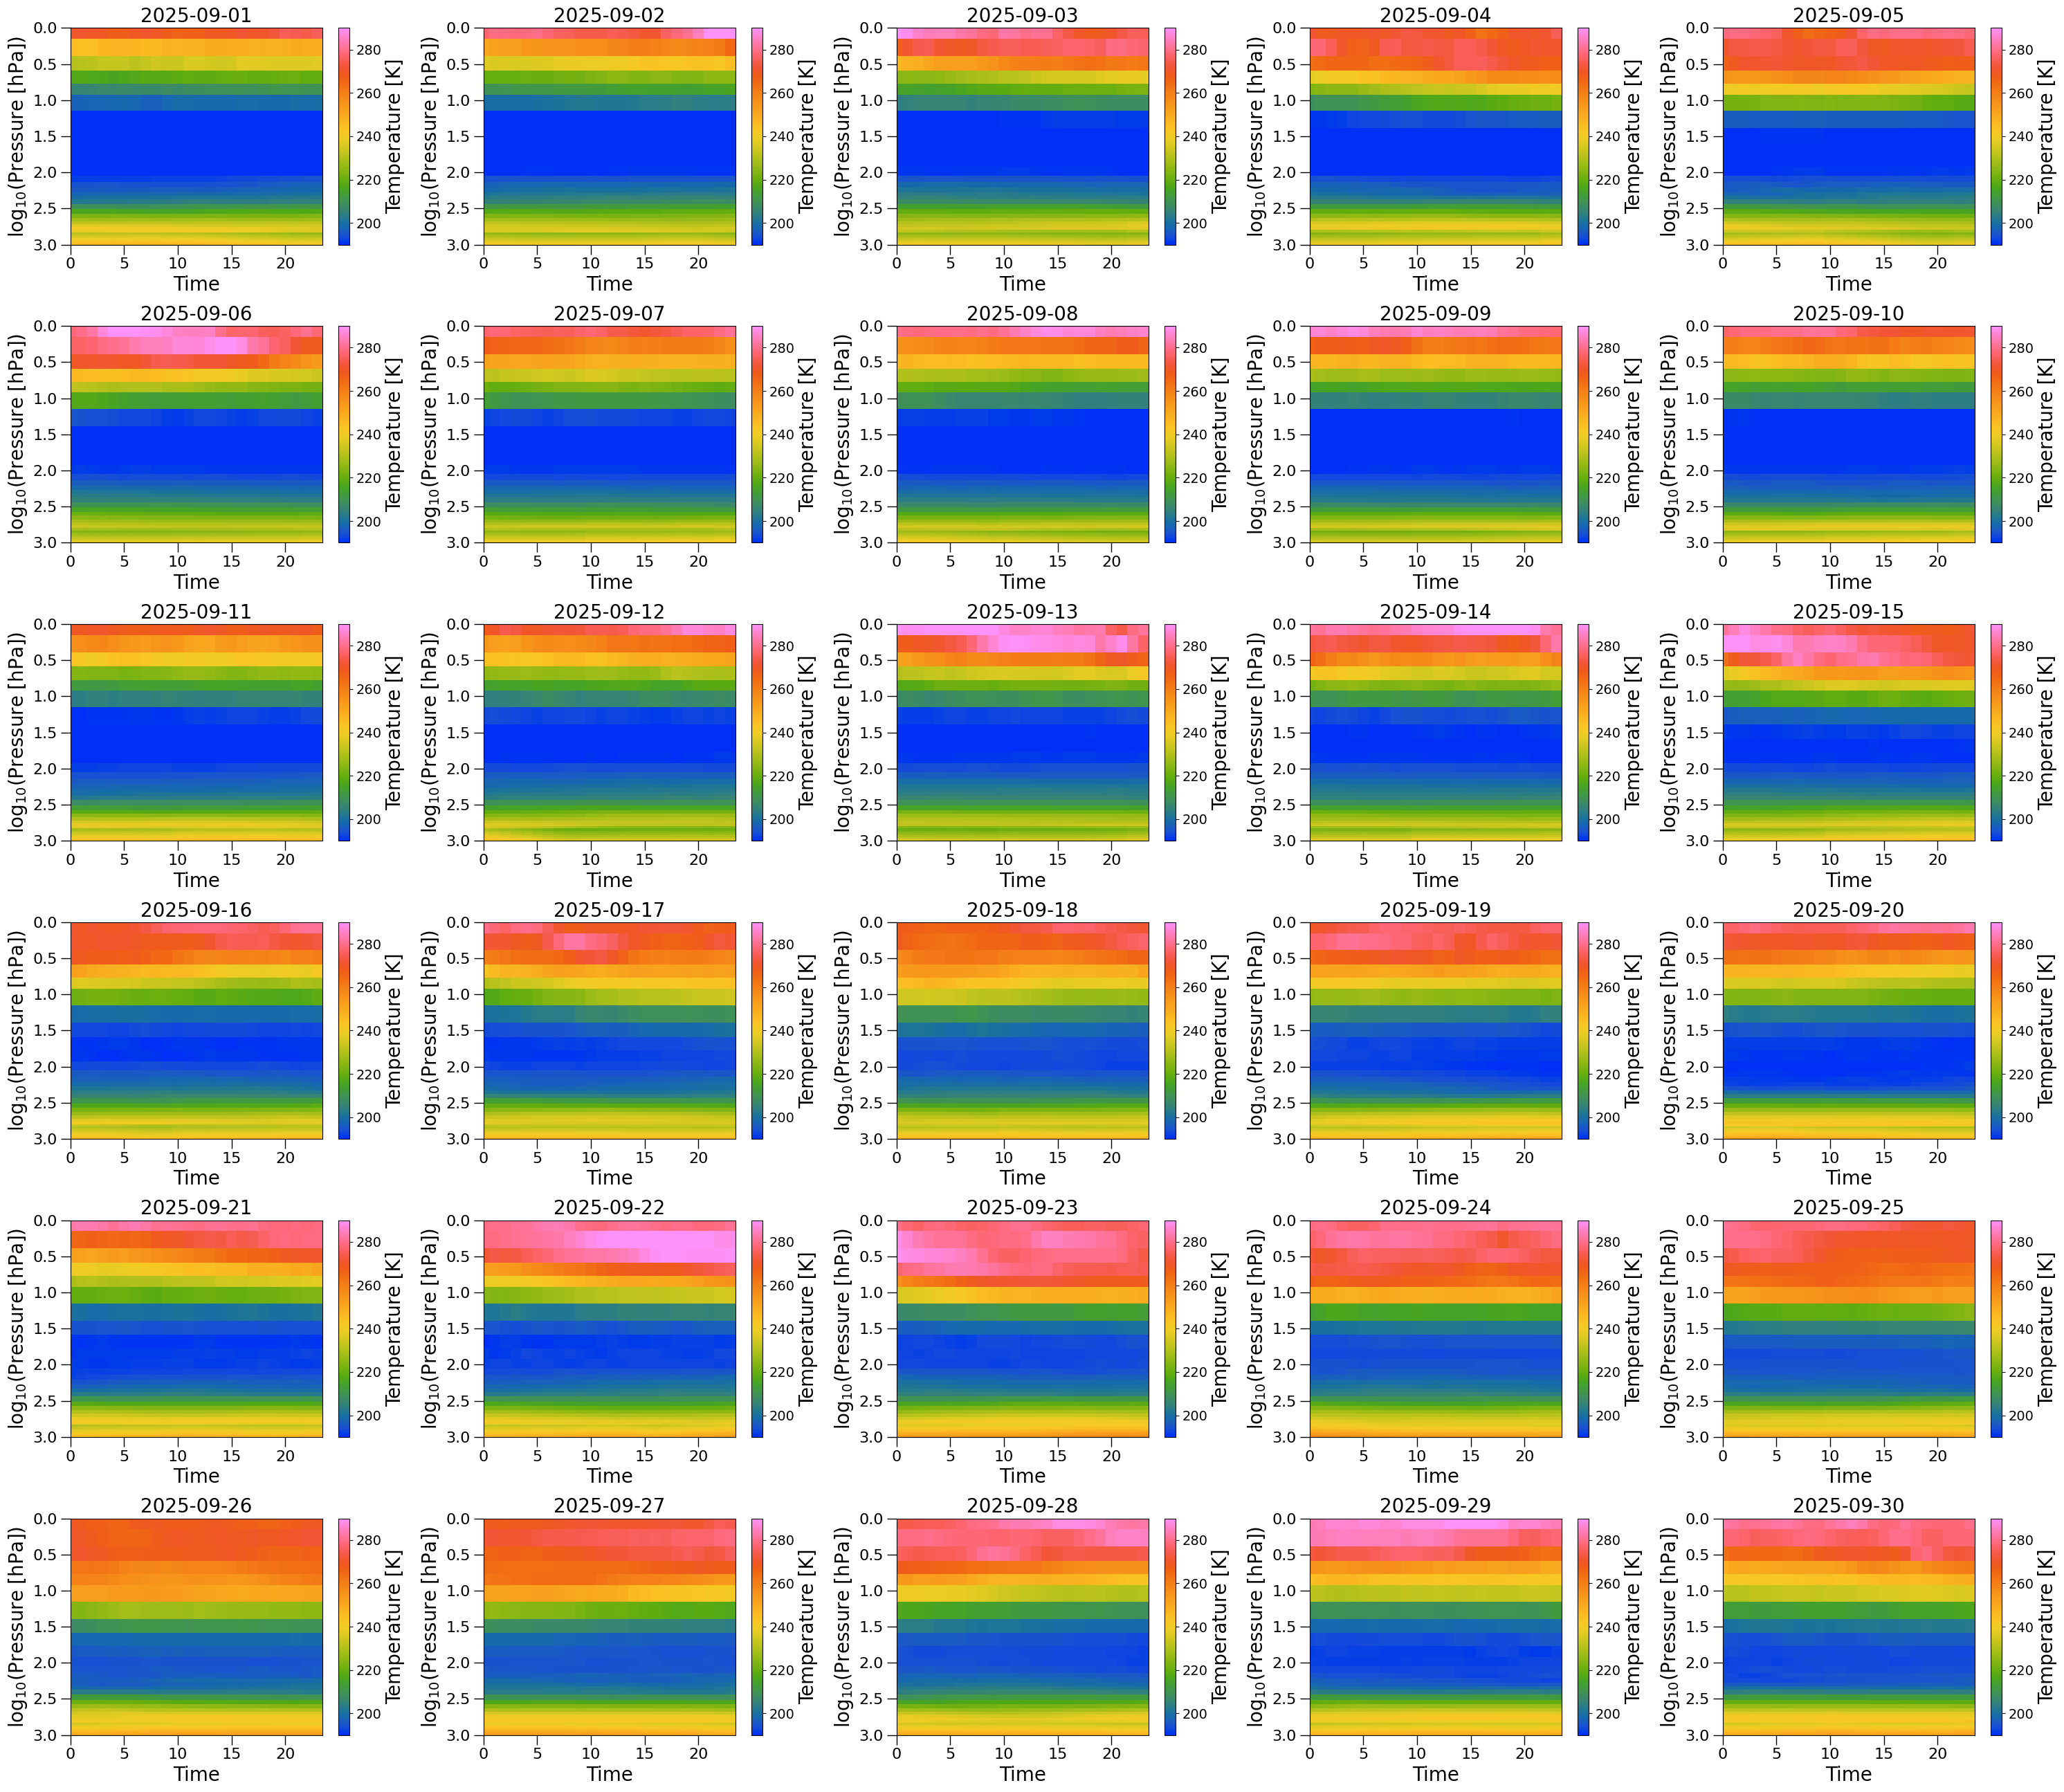

In [12]:
fig, axs = plt.subplots(6,5, figsize = (30,26))
i, j = 0, 0
for day, data in spole_daily_data:
    cm = axs[j][i].pcolormesh(data.time.values.astype('datetime64[h]').astype(int)%24, np.log10(data.isobaricInhPa.values), data.T, shading = 'auto', cmap = cc.cm.CET_R1, vmin = 190, vmax = 290)
    cbar = plt.colorbar(cm)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(r'Temperature [K]', fontsize = 20)
    axs[j][i].set_ylim(0,3)
    axs[j][i].set_xlim(0,23.5)
    axs[j][i].set_xlabel(f'Time', fontsize = 20)
    axs[j][i].set_ylabel(r'$\mathrm{log}_{10}$(Pressure [hPa])', fontsize = 20)
    axs[j][i].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
    axs[j][i].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
    axs[j][i].invert_yaxis()
    axs[j][i].set_title(day, fontsize = 20)
    i+=1
    if i%5 == 0:
        i = 0
        j += 1
fig.tight_layout()

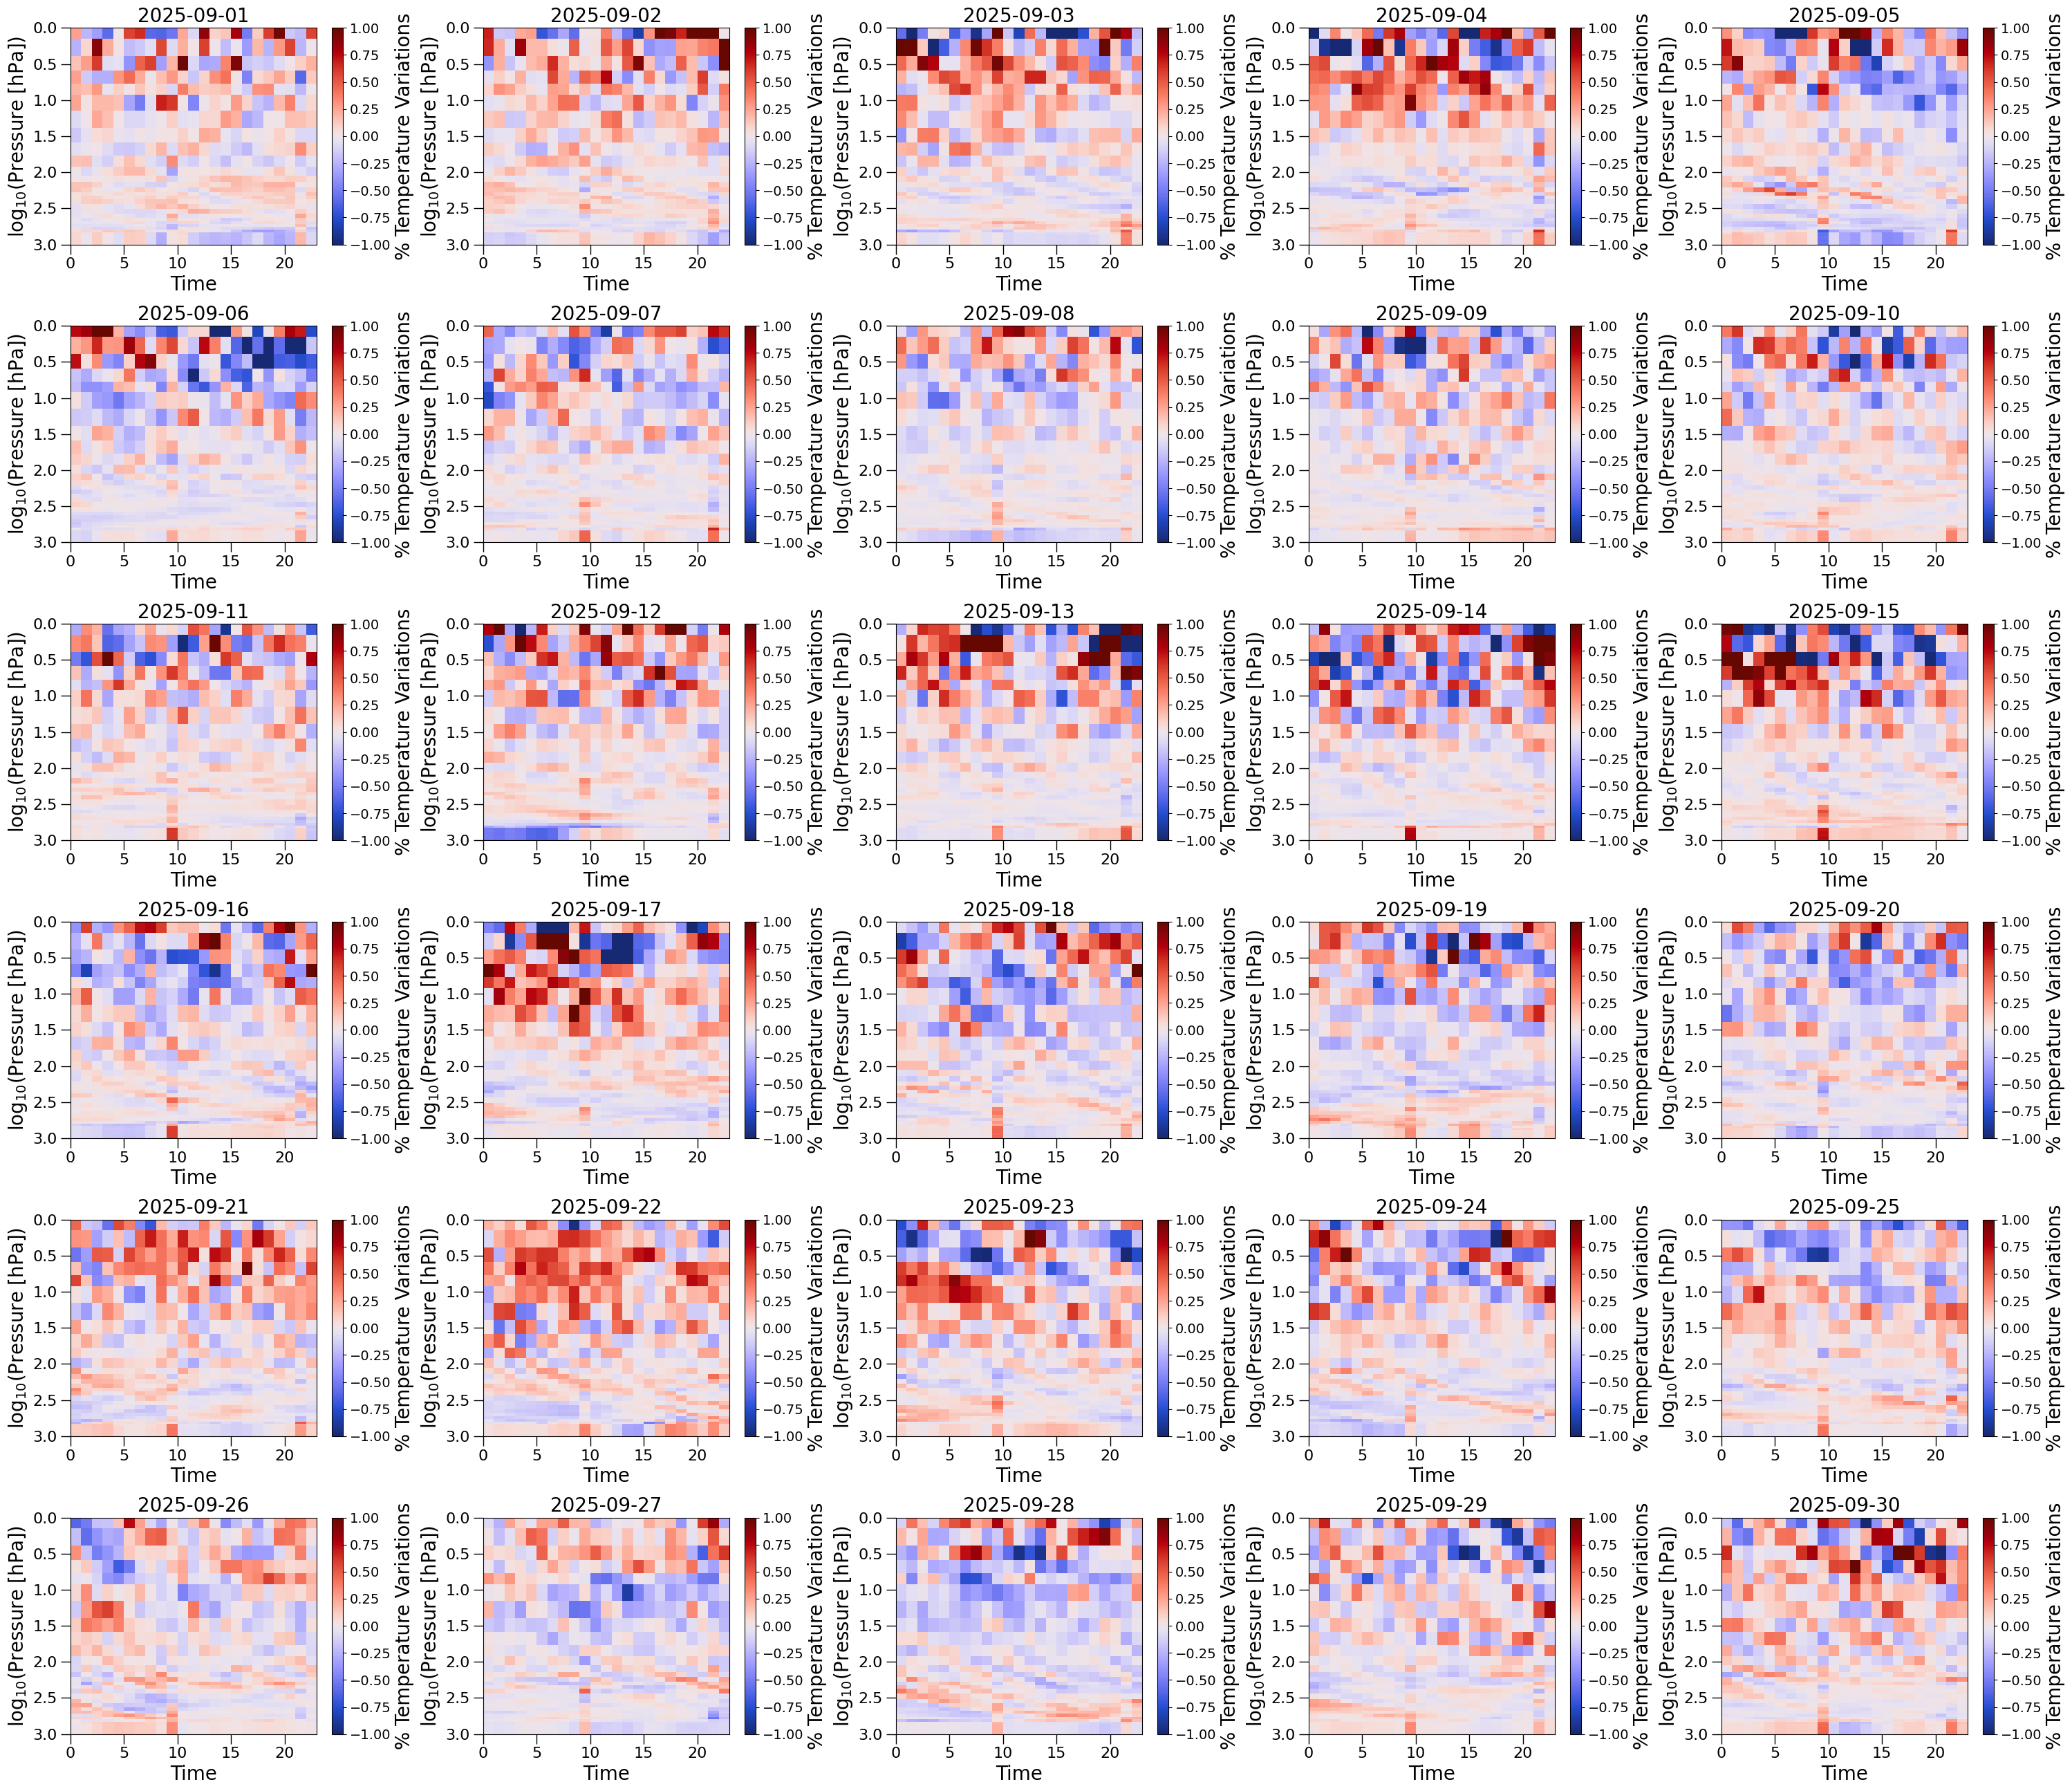

In [13]:
fig, axs = plt.subplots(6,5, figsize = (30,26))
i, j = 0, 0
for day, data in spole_daily_data:
    old_bins = data.time.values.astype('datetime64[h]').astype(int)%24
    new_bins = (old_bins[1:]+old_bins[:-1])/2
    pdiff = 100*(data.T.values[:,1:]-data.T.values[:,:-1])/data.T.values[:,:-1]
    norm = colors.TwoSlopeNorm(0, vmin = -1, vmax = 1)
    cm = axs[j][i].pcolormesh(new_bins, np.log10(data.isobaricInhPa.values), pdiff, shading = 'auto', cmap = cc.cm.diverging_bwr_20_95_c54, norm = norm)
    cbar = plt.colorbar(cm)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(r'% Temperature Variations', fontsize = 20)
    axs[j][i].set_ylim(0,3)
    axs[j][i].set_xlim(0,23)
    axs[j][i].set_xlabel(f'Time', fontsize = 20)
    axs[j][i].set_ylabel(r'$\mathrm{log}_{10}$(Pressure [hPa])', fontsize = 20)
    axs[j][i].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
    axs[j][i].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
    axs[j][i].invert_yaxis()
    axs[j][i].set_title(day, fontsize = 20)
    i+=1
    if i%5 == 0:
        i = 0
        j += 1
fig.tight_layout()

# Test

In [7]:
test_date, test_data = test = next(iter(spole_daily_data))
test = test_data.sel(time = '2025-09-01T11:00:00.000000000')

In [9]:
print(test.values)
print(test.isobaricInhPa.values)

[247.34476 246.13736 244.90196 243.70662 242.40685 241.19373 239.82207
 238.49579 237.13185 235.69312 234.15237 231.01904 240.25311 238.92244
 235.33786 232.03323 228.16531 222.61153 215.28114 210.1011  204.10521
 201.19408 198.87059 196.28691 194.068   191.9819  189.7119  186.74994
 184.05074 183.0275  184.91026 199.30122 208.17659 218.94649 236.09161
 247.94371 266.98923]
[1000.  975.  950.  925.  900.  875.  850.  825.  800.  775.  750.  700.
  650.  600.  550.  500.  450.  400.  350.  300.  250.  225.  200.  175.
  150.  125.  100.   70.   50.   30.   20.   10.    7.    5.    3.    2.
    1.]


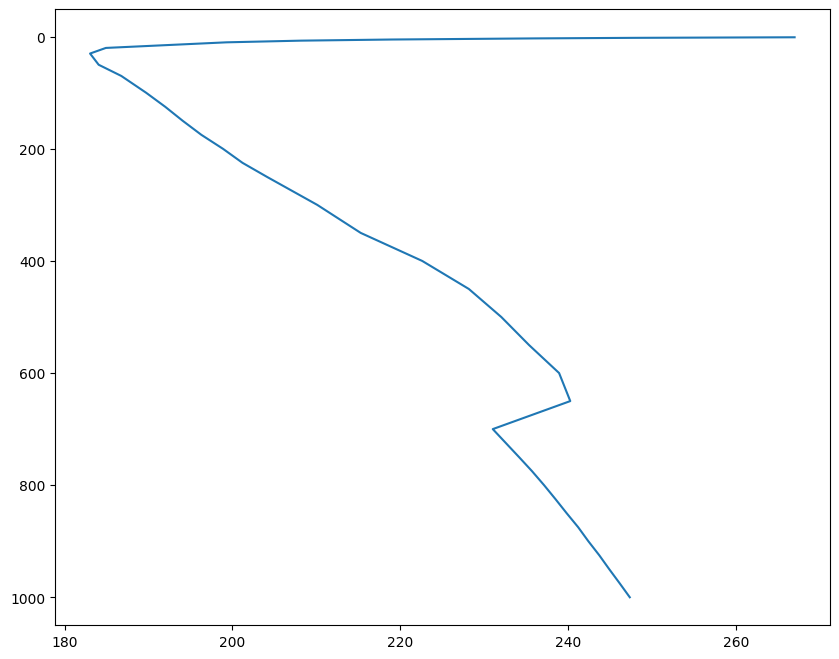

In [45]:
fig, ax = plt.subplots(1,1,figsize = (10,8))
ax.plot(test.values,test.isobaricInhPa.values)
ax.invert_yaxis()

In [63]:
print(data_one.isobaricInhPa.values)

[1000.  975.  950.  925.  900.  875.  850.  825.  800.  775.  750.  700.
  650.  600.  550.  500.  450.  400.  350.  300.  250.  225.  200.  175.
  150.  125.  100.   70.   50.   30.   20.   10.    7.    5.    3.    2.
    1.]


In [67]:
print(data_one.sel(isobaricInhPa = 1000))

<xarray.DataArray 't' (time: 24)> Size: 96B
array([247.21948, 247.40073, 247.35579, 247.6322 , 247.67336, 247.51077,
       247.7971 , 248.04756, 247.8398 , 247.14844, 247.206  , 247.34476,
       247.0064 , 246.48242, 245.8953 , 245.34735, 244.73392, 244.3002 ,
       244.0943 , 243.52098, 242.7633 , 242.17361, 242.60925, 242.39279],
      dtype=float32)
Coordinates:
    number         int64 8B 0
  * time           (time) datetime64[ns] 192B 2025-09-01 ... 2025-09-01T23:00:00
    step           timedelta64[ns] 8B 00:00:00
    isobaricInhPa  float64 8B 1e+03
    latitude       float64 8B -90.0
    longitude      float64 8B -180.0
    valid_time     (time) datetime64[ns] 192B 2025-09-01 ... 2025-09-01T23:00:00
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      25
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    G

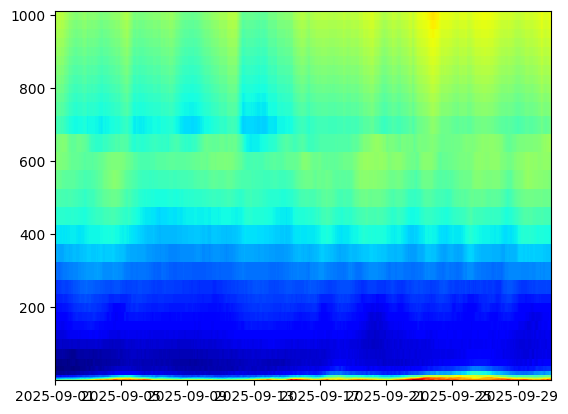

In [21]:
plt.pcolormesh(spole_data.time.values, spole_data.isobaricInhPa.values, spole_data.T, shading = 'auto', cmap = 'jet')

In [14]:
print(spole_data.time.values)

['2025-09-01T00:00:00.000000000' '2025-09-01T01:00:00.000000000'
 '2025-09-01T02:00:00.000000000' '2025-09-01T03:00:00.000000000'
 '2025-09-01T04:00:00.000000000' '2025-09-01T05:00:00.000000000'
 '2025-09-01T06:00:00.000000000' '2025-09-01T07:00:00.000000000'
 '2025-09-01T08:00:00.000000000' '2025-09-01T09:00:00.000000000'
 '2025-09-01T10:00:00.000000000' '2025-09-01T11:00:00.000000000'
 '2025-09-01T12:00:00.000000000' '2025-09-01T13:00:00.000000000'
 '2025-09-01T14:00:00.000000000' '2025-09-01T15:00:00.000000000'
 '2025-09-01T16:00:00.000000000' '2025-09-01T17:00:00.000000000'
 '2025-09-01T18:00:00.000000000' '2025-09-01T19:00:00.000000000'
 '2025-09-01T20:00:00.000000000' '2025-09-01T21:00:00.000000000'
 '2025-09-01T22:00:00.000000000' '2025-09-01T23:00:00.000000000'
 '2025-09-02T00:00:00.000000000' '2025-09-02T01:00:00.000000000'
 '2025-09-02T02:00:00.000000000' '2025-09-02T03:00:00.000000000'
 '2025-09-02T04:00:00.000000000' '2025-09-02T05:00:00.000000000'
 '2025-09-02T06:00:00.000

In [6]:
first_test = ds.t.sel(time = '2016-01-01T12:00:00', latitude = '-90', longitude = '179.75').data
second_test = ds.t.sel(time = '2016-01-01T10:00:00', latitude = '-90', longitude = '179.75').data
pressure_levels = ds.t.sel(time = '2016-01-01T23:00:00', latitude = '-90', longitude = '179.75').isobaricInhPa.data
print(pressure_levels)

[1000.  975.  950.  925.  900.  875.  850.  825.  800.  775.  750.  700.
  650.  600.  550.  500.  450.  400.  350.  300.  250.  225.  200.  175.
  150.  125.  100.   70.   50.   30.   20.   10.    7.    5.    3.    2.
    1.]


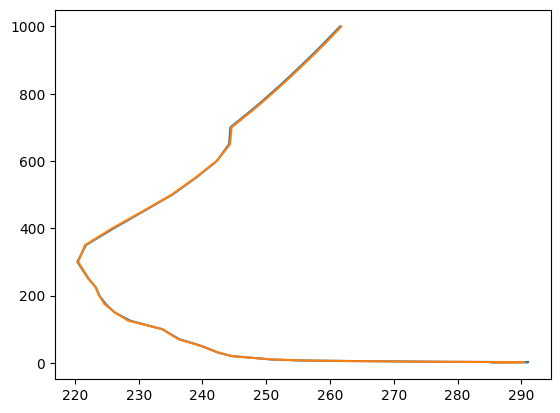

In [7]:
plt.plot(first_test, pressure_levels)
plt.plot(second_test, pressure_levels)
# plt.ylim(bottom = 0, top = 50)